## Problem 1

Consider the set of all {\bf closed} intervals in the real line with
  non-zero length:
  $$\mathcal{B} = \{[a, b] : a < b\}.$$
  Is this a valid basis for a topology on $\mathbb{R}$? Why or why not?



**Solution:** No, this is not a valid basis topology on $\mathbb{R}$. Consider the intersection of $B_1 = [a,b]$ and $B_2 = [b,c]$. $B_1 \cap B_2 = [b]$, but there is no $B_3 \subset [b]$ in our basis. Therefore the set of all closed intervals that are not singletons does *not* form a valid basis topology on $\mathbb{R}$.

## Problem 2
Let $Y$ be a subspace of a topological space $X$ with basis
  $\mathcal{B}$. Show that the sets $\{B \cap Y : B \in \mathcal{B}\}$ form a
  basis for the subspace topology of $Y$.

Consider a set $U$ in the topology of $Y$, $U \in Y$. The subspace topology of $Y$ is formed by $Y \cap U_x$, where $U_x$ is in the topology of $X$. Becuase $X$ has the basis $ \mathcal{B}$, any set $U_x \in X$ can be built by an arbitrary union of $B \in  \mathcal{B_x}$. So $U_x = \bigcup_\alpha B_\alpha$ and $U = Y \cap \bigcup_ \alpha B_\alpha = U = \bigcup_\alpha Y \cap B_\alpha$. This shows that our basis generates the subspace topology of $Y$. Lets verify the 2 requirements for a basis of a topology:

1. Let $y \in Y$. Then $y \in X$, so $\exists B \in \mathcal{B_x}: y \in B$. So $y \in Y \cap B \in \mathcal{B}$.

2. Consider $B_1, B_2, \in \mathcal{B}$ and $y \in B_1 \cap B_2$. Well, $B_1 = Y \cap B_{1x}, B_2 = Y \cap B_{2x}$ Then there exists a $B_{3x} \in \mathcal{B_x}: x \in B_{3x} \subset B_{1x} \cap B_{2x}$. So $y \in B_3 = Y \cap B_{3x} \subset B_1 \cap B_2$.


## Problem 3

Given a metric space $X$ with metric
  $d : X \times X \rightarrow \mathbb{R}$ and a subset $A \subseteq X$, show
  that the metric restricted to $A$, $d |_{A \times A},$ gives the same topology
  as the subspace topology on $A$. **Hint:** you may want to use the result
  from the previous question.

To show that the restricted metric and the subspace topology yeild the same topology, first we will show that all basis balls in the restricted topology basis $\mathcal{B_r}$ are also elements of the subspace topology $\mathcal{B_s}$, second we will show that all $b \in \mathcal{B_r}$ can be constructed as a union of elements in $\mathcal{B_r}$.

First, take a $b_r \in \mathcal{B_r}$. Then $b_r = B_r(a,r), a \in A \subseteq X$. So $b_r = B(a,r) \cap A \in \mathcal{B_s}$. Therefore $\mathcal{B_r} \sub \mathcal{B_s}$.

Second, take an $b_s \in \mathcal{B_s}$, $b_s = B(x, y) \cap A, x \in X$. Then $\forall y \in b_s, \exists r' : 0< r' < r - d(x,y)$, so we can construct another ball using the metric resticted to $A$ (so that all points in this ball are in $A$) $B(y,r')$. Then $B(y,r') \subseteq B(x,r)$, since $\forall z \in (y,r'), z \in A,$ and $d(x,z) \leq d(x,y) + d(y,z) < d(x,y) + d(y,z) < d(x,y) + r - d(x,y) = r$. So $d(x,z) < r$ and $z \in B(x,r) \in A$. 

Therefore for every $b_s \in \mathcal{B_s}$, $b_s = \bigcup_\Gamma b_\gamma, b_\gamma \in \mathcal{B_r}$. This shows these topologies are equivalent.

## Problem 4


Write a Python function to compute the stereographic projection,
  $f: S^2 \rightarrow \mathbb{R}^2$, from the north pole $(0,0,1)$ of the
  2-sphere to the $z = 0$ plane. You may want to see the Wikipedia page for the
  equation.

a. What is the image of a longitudinal line, i.e., a great circle passing
    through the north and south poles? Use your function to plot several images
    of logitudinal lines in the plane.

b. What is the image of a latitude line, i.e., a circle formed by
    intersection with a horizontal plane ($z = \mathrm{const.}$)? Plot several
    images of latitude lines in the plane.

c. What is the image of an arbitrary great circle (one that is {\bf not} a
    longitudinal line or the equator)? Again, plot several in the plane.


In [15]:
import numpy as np
def projection(theta, phi):
    return (np.sin(phi) / (1- np.cos(phi))) * (np.cos(theta), np.sin(theta))

def projection_xyz(x,y,z):
    X = x/(1-z)
    Y = y/(1-z)

    return X, Y

### Solution for part **a**:

Longitudinal lines on the sphere are projected onto the $X-Y$ plane as straight lines going through the origin of infinite length.

In [16]:
## plotting some great circles through the sphere, then the projection on the plane

thetas = np.array((np.pi/4, 3, 4.5, np.pi * 11/ 6))
#print(thetas.shape)

phis = np.linspace(0.1, np.pi * 2,20, endpoint=False)
#print(phis.shape)


mat = np.array(np.broadcast_arrays(thetas[:,None] ,phis[None, :]))
circles = np.stack(mat, axis= -1)

In [17]:
import matplotlib.pyplot as plt

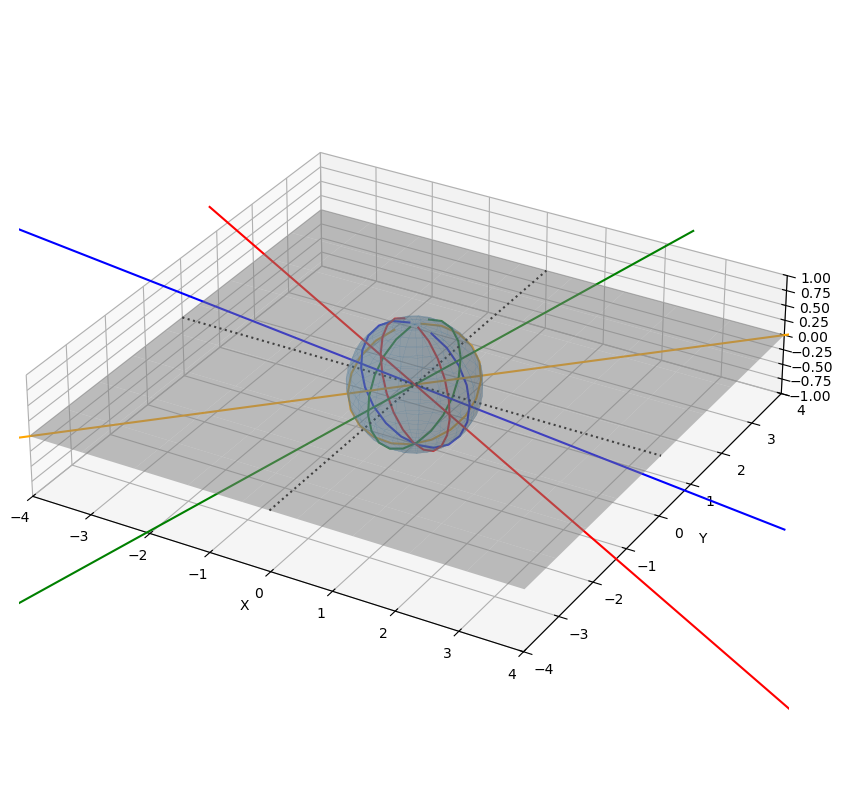

In [18]:
# do plotting

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")

colors = ["orange", "blue", "green", "red"]

# plot x-y lines

x = np.linspace(-4, 4, 10)
x_y = np.zeros_like(x)

y = np.linspace(-4, 4, 10)
y_x = np.zeros_like(y)


#add circles
for i, circle in enumerate(circles):

    thetas = circle[:,0]
    phis = circle[:,1]

    circle_xyz = np.stack(
    (
    np.cos(thetas) * np.sin(phis),
    np.sin(thetas) * np.sin(phis),
    np.cos(phis)
    ), axis=-1
    )
    
    # print(circle_xyz.shape)
    ax.plot(circle_xyz[:, 0],circle_xyz[:, 1],circle_xyz[:, 2], color = colors[i])


# add projected lines

for i, pre_proj_line in enumerate(circles):
    proj_line = projection(pre_proj_line[:,0], pre_proj_line[:,1]).T

    # print(proj_line.shape)

    ax.plot(proj_line[:,0], proj_line[:,1], np.zeros_like(projection), color = colors[i])



ax.plot(x, x_y, color = "black", linestyle = ":")
ax.plot(x_y, y, color = "black", linestyle = ":")
# make the sphere
thetas = np.linspace(0, 2*np.pi, 20)
phis = np.linspace(0, np.pi, 20)
x = np.outer(np.cos(thetas), np.sin(phis))
y = np.outer(np.sin(thetas), np.sin(phis))
z = np.outer(np.ones_like(thetas), np.cos(phis))

ax.plot_surface(x, y, z, rstride=1, cstride=1, alpha = 0.21, antialiased=True)

ax.plot_wireframe(x, y, z, rstride=1, cstride=1, linewidth=.1, alpha = 1, antialiased=True)

#make the plane
x = np.linspace(-4, 4, 10)
y = np.linspace(-4, 4, 10)

X, Y = np.meshgrid(x,x)

Z = np.zeros_like(X)

ax.plot_surface(X, Y, Z, alpha=.5, color = "grey",   shade=False
)

# Keep aspect ratio roughly equal. <--- chat cooked this one up
ax.set_box_aspect((4, 4, 1))
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-1, 1)

ax.set_autoscale_on(False)

### Solution to part **b**

Latitudinal lines will map onto the $X-Y$ plane as circles centered at the origin.

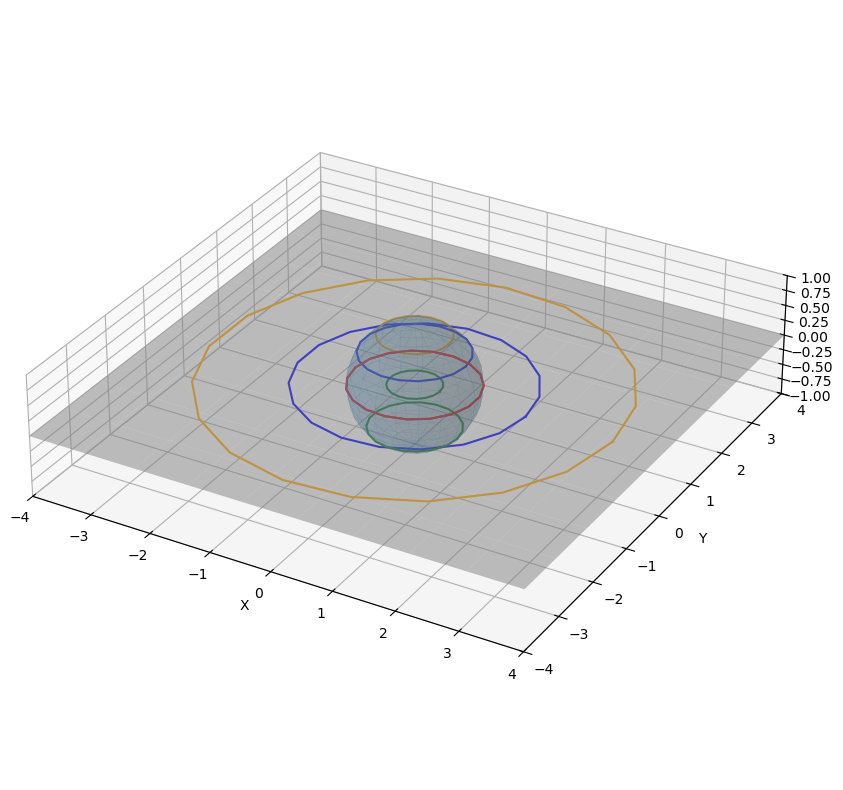

In [19]:
phis = np.array([.6,1, 3 * np.pi / 4, 3 * np.pi / 2])

thetas = np.linspace(0, 2 * np.pi, 20, endpoint=True)

mat = np.array(np.broadcast_arrays(phis[None, :], thetas[:,None] ,))
mat.T.shape


# do plotting

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")

colors = ["orange", "blue", "green", "red"]

# plot x-y lines

x = np.linspace(-4, 4, 10)
x_y = np.zeros_like(x)

y = np.linspace(-4, 4, 10)
y_x = np.zeros_like(y)

# make the sphere
thetas = np.linspace(0, 2*np.pi, 20)
phis = np.linspace(0, np.pi, 20)
x = np.outer(np.cos(thetas), np.sin(phis))
y = np.outer(np.sin(thetas), np.sin(phis))
z = np.outer(np.ones_like(thetas), np.cos(phis))

ax.plot_surface(x, y, z, rstride=1, cstride=1, alpha = 0.21, antialiased=True)

ax.plot_wireframe(x, y, z, rstride=1, cstride=1, linewidth=.1, alpha = 1, antialiased=True)


#make the plane
x = np.linspace(-4, 4, 10)
y = np.linspace(-4, 4, 10)

X, Y = np.meshgrid(x,x)

Z = np.zeros_like(X)

ax.plot_surface(X, Y, Z, alpha=.5, color = "grey",   shade=False
)

for i, circle in enumerate(mat.T):
    X, Y = projection(circle[:,1], circle[:,0])
    z = np.zeros_like(X)

    ax.plot(X, Y, z, color = colors[i])



for i, circle in enumerate(mat.T):

    phis = circle[:,0]
    thetas = circle[:,1]

    circle_xyz = np.stack(
    (
    np.cos(thetas) * np.sin(phis),
    np.sin(thetas) * np.sin(phis),
    np.cos(phis)
    ), axis=-1
    )
    
    # print(circle_xyz.shape)
    ax.plot(circle_xyz[:, 0],circle_xyz[:, 1],circle_xyz[:, 2], color = colors[i])


# Keep aspect ratio roughly equal. <--- chat cooked this one up
ax.set_box_aspect((4, 4, 1))
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-1, 1)

ax.set_autoscale_on(False)

### Solution to part **c**:

The projection of an arbitrary great circle would look like an elipse as long as the great circle is not a longitudinal line.

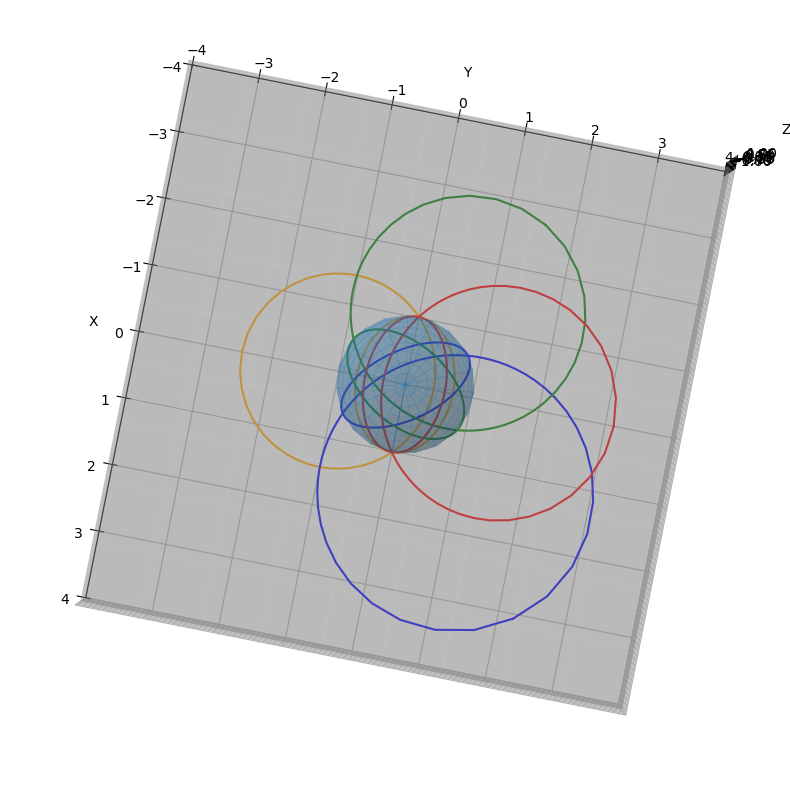

In [29]:


# do plotting

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")

ax.view_init(elev=90, azim=10) 


colors = ["orange", "blue", "green", "red"]

# plot x-y lines

x = np.linspace(-4, 4, 10)
x_y = np.zeros_like(x)

y = np.linspace(-4, 4, 10)
y_x = np.zeros_like(y)

# make the sphere
thetas = np.linspace(0, 2*np.pi, 20)
phis = np.linspace(0, np.pi, 20)
x = np.outer(np.cos(thetas), np.sin(phis))
y = np.outer(np.sin(thetas), np.sin(phis))
z = np.outer(np.ones_like(thetas), np.cos(phis))

ax.plot_surface(x, y, z, rstride=1, cstride=1, alpha = 0.21, antialiased=True)

ax.plot_wireframe(x, y, z, rstride=1, cstride=1, linewidth=.1, alpha = 1, antialiased=True)


#make the plane
x = np.linspace(-4, 4, 10)
y = np.linspace(-4, 4, 10)

X, Y = np.meshgrid(x,x)

Z = np.zeros_like(X)

ax.plot_surface(X, Y, Z, alpha=.5, color = "grey",   shade=False
)




# make the great circle

def great_circle(t, z_ofset = np.pi/4, ):
    z = np.cos(z_ofset) * np.cos(t)
    y = np.sin(z_ofset) * np.cos(t)
    x = np.sin(t)
    return x, y, z

ts = np.linspace(0,2*np.pi, 80, endpoint=True)


# circle one
circle_x,circle_y,circle_z = great_circle(ts)

theta = np.pi 
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

circle_x, circle_y = R @ np.array([circle_x, circle_y])

ax.plot(circle_x, circle_y, circle_z, color = colors[0])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[0])

#cirlce two


circle_y,circle_x,circle_z = great_circle(ts, z_ofset=np.pi/6)

# apply rotation in the x, y plane
theta = np.pi/5
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

circle_x, circle_y = R @ np.array([circle_x, circle_y])

ax.plot(circle_x, circle_y, circle_z, color = colors[1])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[1])

#circle three

circle_x,circle_y,circle_z = great_circle(ts, z_ofset=np.pi/5)

theta = np.pi/3
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

circle_x, circle_y = R @ np.array([circle_x, circle_y])

ax.plot(circle_x, circle_y, circle_z, color = colors[2])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[2])

#circle four

circle_x,circle_y,circle_z = great_circle(ts, z_ofset=np.pi/5)


theta = np.pi * 7 / 6
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

ax.plot(circle_x, -circle_y, circle_z, color = colors[3])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[3])




# for i, circle in enumerate(mat.T):
    # X, Y = projection(circle[:,1], circle[:,0])
    # z = np.zeros_like(X)

    # ax.plot(X, Y, z, color = colors[i])



# for i, circle in enumerate(mat.T):

    # phis = circle[:,0]
    # thetas = circle[:,1]

    # circle_xyz = np.stack(
    # (
    # np.cos(thetas) * np.sin(phis),
    # np.sin(thetas) * np.sin(phis),
    # np.cos(phis)
    # ), axis=-1
    # )
    
    # # print(circle_xyz.shape)
    # ax.plot(circle_xyz[:, 0],circle_xyz[:, 1],circle_xyz[:, 2], color = colors[i])


# Keep aspect ratio roughly equal. <--- chat cooked this one up
ax.set_box_aspect((4, 4, 1))
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-1, 1)

ax.set_autoscale_on(False)

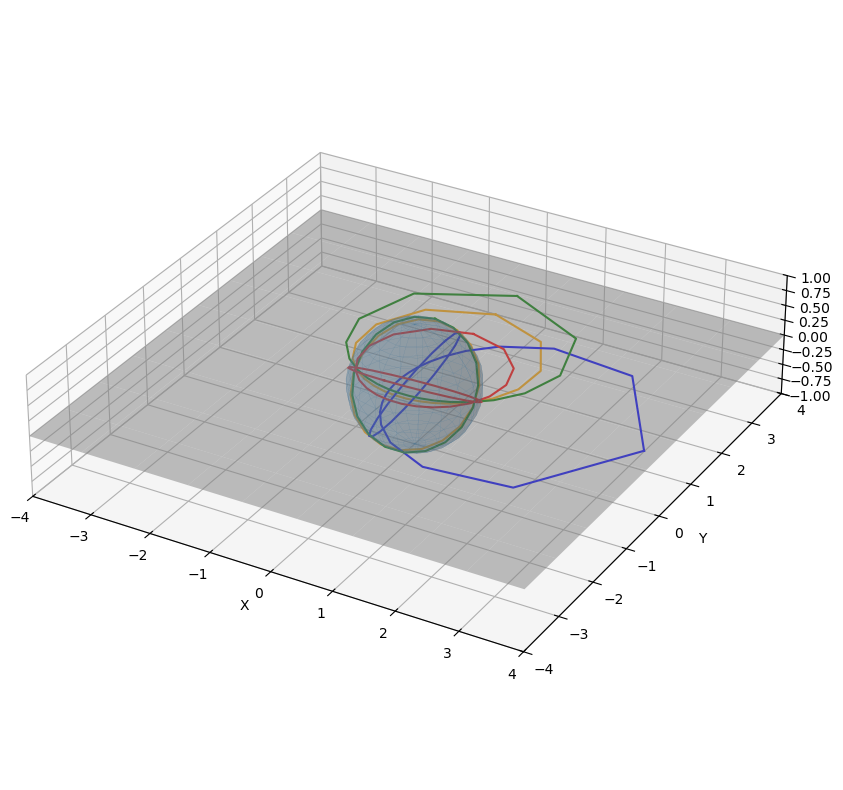

In [27]:


# do plotting

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")

colors = ["orange", "blue", "green", "red"]

# plot x-y lines

x = np.linspace(-4, 4, 10)
x_y = np.zeros_like(x)

y = np.linspace(-4, 4, 10)
y_x = np.zeros_like(y)

# make the sphere
thetas = np.linspace(0, 2*np.pi, 20)
phis = np.linspace(0, np.pi, 20)
x = np.outer(np.cos(thetas), np.sin(phis))
y = np.outer(np.sin(thetas), np.sin(phis))
z = np.outer(np.ones_like(thetas), np.cos(phis))

ax.plot_surface(x, y, z, rstride=1, cstride=1, alpha = 0.21, antialiased=True)

ax.plot_wireframe(x, y, z, rstride=1, cstride=1, linewidth=.1, alpha = 1, antialiased=True)


#make the plane
x = np.linspace(-4, 4, 10)
y = np.linspace(-4, 4, 10)

X, Y = np.meshgrid(x,x)

Z = np.zeros_like(X)

ax.plot_surface(X, Y, Z, alpha=.5, color = "grey",   shade=False
)


# make the great circle

def great_circle(t, z_ofset = np.pi/4, ):
    z = np.cos(z_ofset) * np.cos(t)
    y = np.sin(z_ofset) * np.cos(t)
    x = np.sin(t)
    return x, y, z

ts = np.linspace(0,2*np.pi, 20, endpoint=True)


# circle one
circle_x,circle_y,circle_z = great_circle(ts)

ax.plot(circle_x, circle_y, circle_z, color = colors[0])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[0])

#cirlce two


circle_y,circle_x,circle_z = great_circle(ts, z_ofset=np.pi/6)

ax.plot(circle_x, circle_y, circle_z, color = colors[1])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[1])

#circle three

circle_x,circle_y,circle_z = great_circle(ts, z_ofset=np.pi/5)

ax.plot(circle_x, circle_y, circle_z, color = colors[2])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[2])

#circle four

circle_x,circle_y,circle_z = great_circle(ts, z_ofset=np.pi/3)

ax.plot(circle_x, -circle_y, circle_z, color = colors[3])

proj_x, proj_y= projection_xyz(circle_x, circle_y, circle_z)

proj_z = np.zeros_like(proj_x)

ax.plot(proj_x, proj_y, proj_z, color = colors[3])



# for i, circle in enumerate(mat.T):
    # X, Y = projection(circle[:,1], circle[:,0])
    # z = np.zeros_like(X)

    # ax.plot(X, Y, z, color = colors[i])



# for i, circle in enumerate(mat.T):

    # phis = circle[:,0]
    # thetas = circle[:,1]

    # circle_xyz = np.stack(
    # (
    # np.cos(thetas) * np.sin(phis),
    # np.sin(thetas) * np.sin(phis),
    # np.cos(phis)
    # ), axis=-1
    # )
    
    # # print(circle_xyz.shape)
    # ax.plot(circle_xyz[:, 0],circle_xyz[:, 1],circle_xyz[:, 2], color = colors[i])


# Keep aspect ratio roughly equal. <--- chat cooked this one up
ax.set_box_aspect((4, 4, 1))
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-1, 1)

ax.set_autoscale_on(False)

### Problem 5:

A. I think this is really cool. If my hunch is correct. Distance from the equator is pi /2 - distance from a pole. Since we have a unit sphere, distance = angle, so we can compute the cosine distance from the north pole, take the norm of pi/2 - that, and viola, we have distance from the equator. This idea came from this facial recognition model: https://arxiv.org/pdf/1801.07698.

As d increases, our points get closer and closer to the equator of our d-sphere. This means that any point form a uniform distribution tends to get further and further away from the poles. I think this is realated to why the probablility of a point being close to the perimiter of a d-cube gets astronomically high as d increases. The result should be the same if you use a different great circle. This is because we can perform a linear transformation on a hypersphere to make its great circle the equator. Then we could compute distance in the same way and see that our points end up still tending toward the equator.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
rn_g = np.random.default_rng(seed = 42)
d = 2
rn_g.standard_normal(size = (d+1))

array([ 0.30471708, -1.03998411,  0.7504512 ])

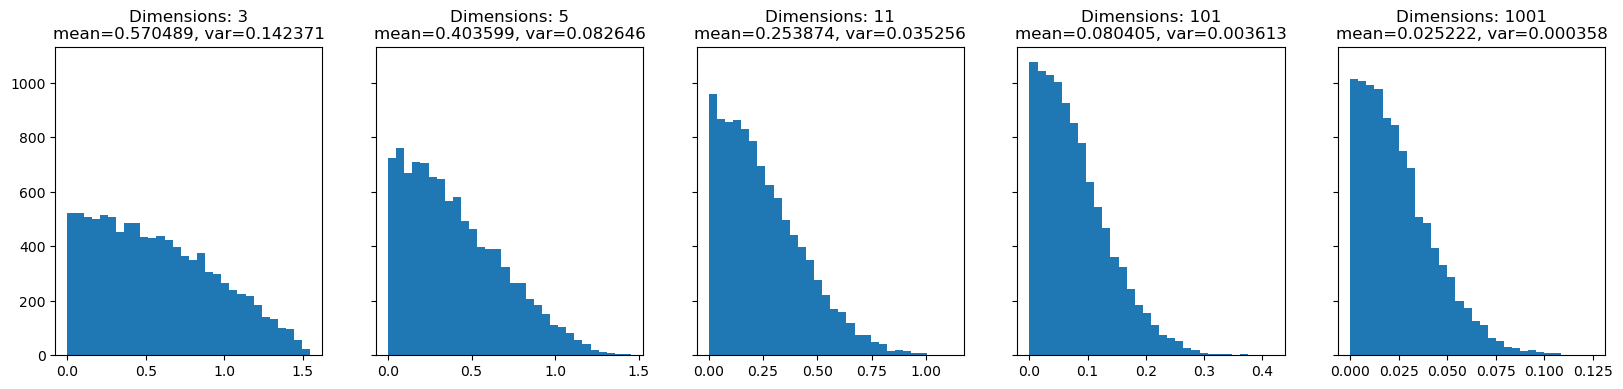

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, d in zip(axes, [2, 4, 10, 100, 1000]):
    distances = []

    for i in range(10000):
        v = rn_g.standard_normal(d + 1)
        v = v / np.linalg.norm(v)
        distance_from_pole = v[0]
        arc_dist_from_pole = np.arccos(distance_from_pole)
        arc_dist_from_equator = np.abs(np.pi / 2 - arc_dist_from_pole)
        distances.append(arc_dist_from_equator)

    ax.hist(distances, bins=30)
    ax.set_title(
        f"Dimensions: {d+1}\n"
        f"mean={np.mean(distances):.6f}, var={np.var(distances):.6f}"
    )

B. These angluar distances approach pi/2 as d increases. This means that uniformly distributed points tend to be at right angles from eachother. I guess this makes sence, since in order to have an angle closer/further than pi/2, you need all the other dimensions to be closer to zero. The probability of that happening over d+1 uniform standard randoms gets so so low.

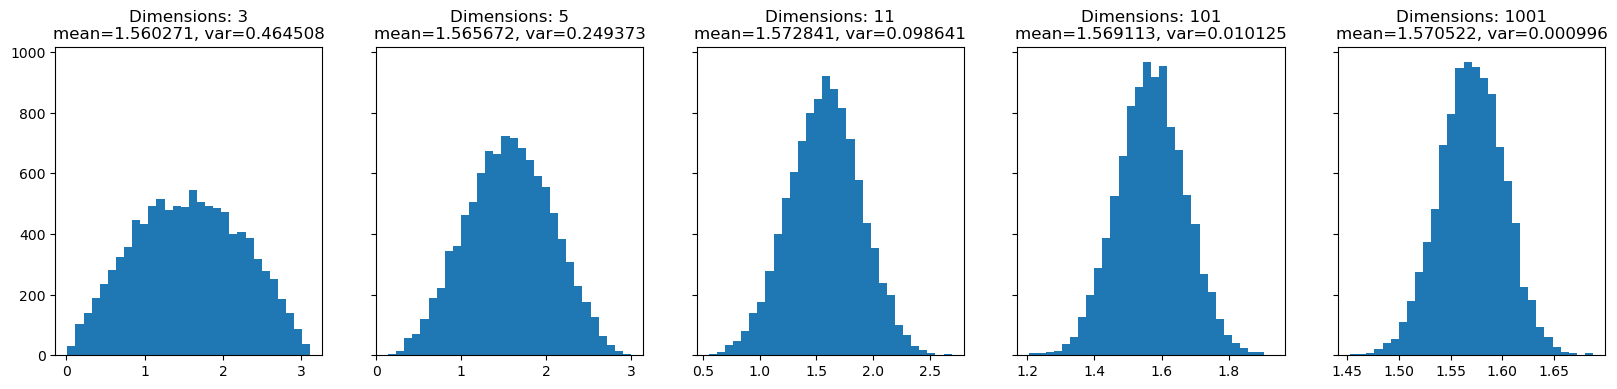

In [13]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, d in zip(axs, [2,4,10,100,1000]):
    distances = []
    for i in range(10000):
        v = rn_g.standard_normal(d+1)
        u = rn_g.standard_normal(d+1)
        v = v / np.linalg.norm(v)
        u = u / np.linalg.norm(u)

        dot = np.dot(u,v)

        angle = np.arccos(dot)

        distances.append(angle)

    ax.hist(distances, bins=30)
    ax.set_title(f"Dimensions: {d+1}\nmean={np.mean(distances):.6f}, var={np.var(distances):.6f}")